imports

In [28]:
import h5py
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

read feature file and print shapes <br>
41860 = 20 time windows x 2093 trials <br>
640 = 10 features x 64 channels


In [29]:
with h5py.File("../dataset_creation/MODE_FEATURES.h5", "r") as f:
    features = f['features'][:]
    labels = f['labels'][:]

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print(labels[0:20])
print(labels[21:40])

Features shape: (41860, 640)
Labels shape: (41860,)
[121 121 121 121 121 121 121 121 121 121 121 121 121 121 121 121 121 121
 121 121]
[122 122 122 122 122 122 122 122 122 122 122 122 122 122 122 122 122 122
 122]


compute correlation

In [30]:
num_windows = 20 
num_trials = features.shape[0] // num_windows
num_features = 10 * 64

correlation_matrix = np.corrcoef(features, rowvar=False)

print("Correlation matrix shape:", correlation_matrix.shape)
print(correlation_matrix)
np.save("mode_features_CM.npy", correlation_matrix)

Correlation matrix shape: (640, 640)
[[1.         0.84694374 0.78560489 ... 0.50980921 0.45438144 0.50492332]
 [0.84694374 1.         0.85746655 ... 0.55989388 0.52976732 0.52184872]
 [0.78560489 0.85746655 1.         ... 0.65486272 0.63990129 0.60461772]
 ...
 [0.50980921 0.55989388 0.65486272 ... 1.         0.86182203 0.88353372]
 [0.45438144 0.52976732 0.63990129 ... 0.86182203 1.         0.74973502]
 [0.50492332 0.52184872 0.60461772 ... 0.88353372 0.74973502 1.        ]]


visualize correlation

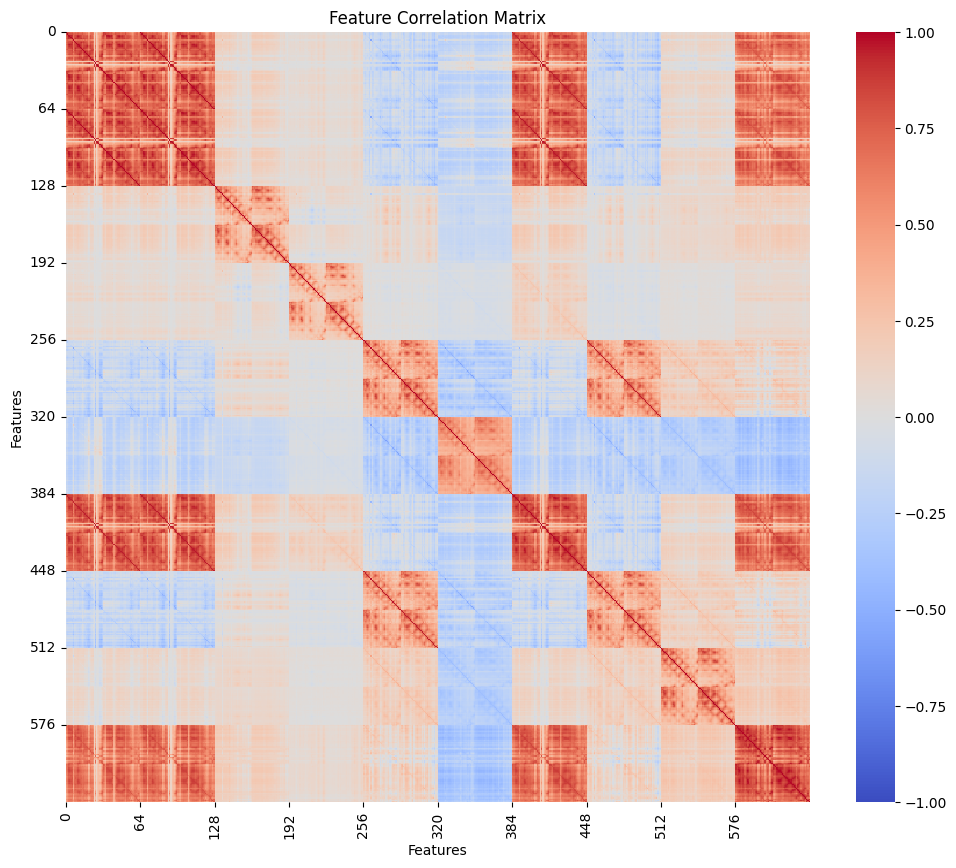

In [31]:
correlation_matrix = np.load("mode_features_CM.npy")

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.xlabel('Features')
plt.ylabel('Features')
tick_positions = np.arange(0, 640, 64)
tick_labels = [str(i) for i in tick_positions]

plt.xticks(tick_positions, tick_labels)
plt.yticks(tick_positions, tick_labels)
plt.show()

boxes of 64 because the feautures are per computed per channel and there are 64 channels <br>
attempting channel aggregation (mean) below, but this does not look good (probably losing too much information)

reshaped_features = features.reshape(-1, 64, 10)
aggregated_features = np.mean(reshaped_features, axis=1)
print("Aggregated Features shape:", aggregated_features.shape)
correlation_matrix_agg = np.corrcoef(aggregated_features, rowvar=False)
print("Correlation matrix shape:", correlation_matrix_agg.shape)
np.save("mode_features_aggregated_CM.npy", correlation_matrix_agg)

correlation_matrix = np.load("mode_features_aggregated_CM.npy")

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

PCA on all channels correlation matrix from before

[29.1 14.   4.6  3.7  3.4  2.8  1.9  1.6  1.5  1.3  1.1  1.   0.9  0.9
  0.8  0.8  0.7  0.6  0.6  0.6]
71.89999999999999


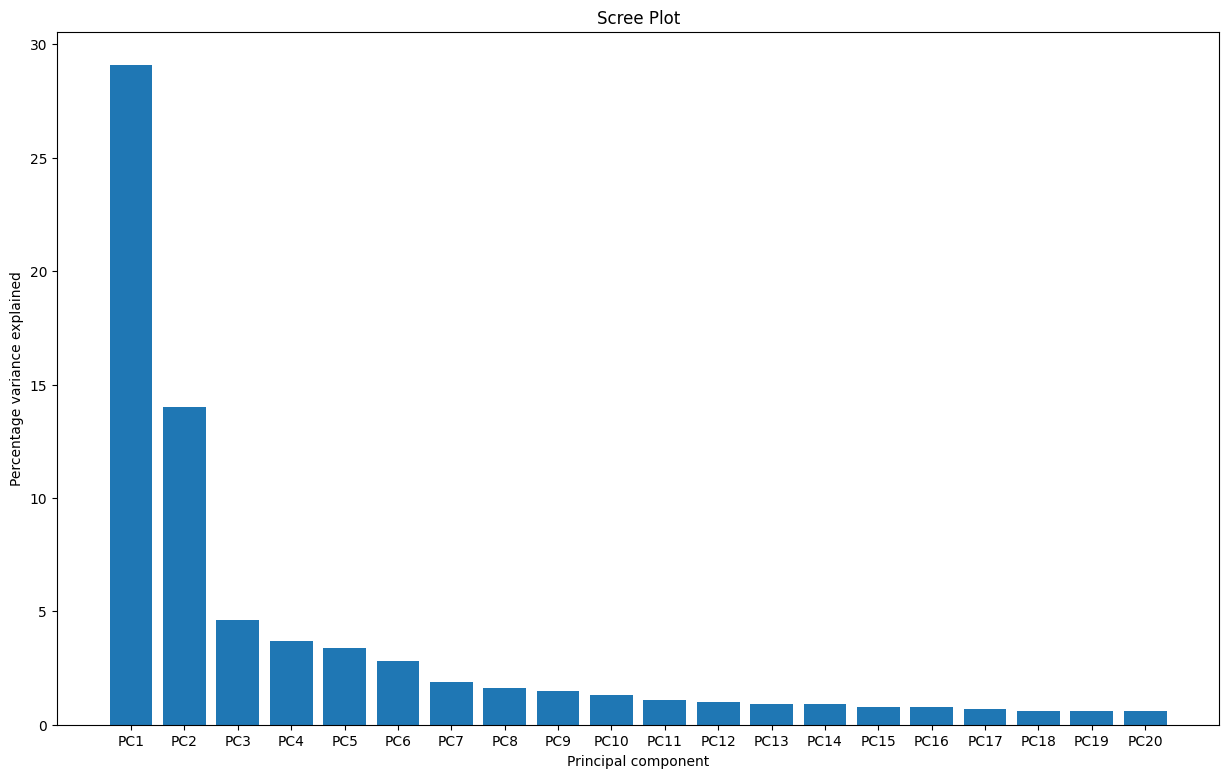

70.7
66.0


In [32]:
# only first 20 PCs
scaled_data = StandardScaler().fit_transform(features)
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)
percentage_variance = np.round(pca.explained_variance_ratio_*100, decimals=1)[:20]
print(percentage_variance)
print(sum(percentage_variance))
#labels = ["PC" + str(x) for x in range(1, len(percentage_variance)+1)]
labels_unique = ["PC" + str(x) for x in range(1, 21)]
#plt.bar(x=range(1, len(percentage_variance)+1), height= percentage_variance,tick_label=labels)
plt.figure(figsize=(15,9))
plt.bar(x=range(1, 21), height= percentage_variance,tick_label=labels_unique)
plt.xlabel("Principal component")
plt.ylabel("Percentage variance explained")
plt.title("Scree Plot")
plt.show()

print(sum(percentage_variance[:18])) #ca. 70%
print(sum(percentage_variance[:12])) #the ones that explain at least 1% of the variance: sum = 66%

pca plot the different features

pca_df = pd.DataFrame(pca_data, index=["rms", 
                    "std", 
                    "skewness",
                    "kurtosis", 
                    "app_entropy", 
                    "hurst_exp",
                    "ptp_amp",  
                    "samp_entropy", 
                    "pow_freq_bands",
                    "line_length"], columns = labels)
plt.scatter(pca_df.PC1, pca_df.PC2)

which features are responsible for explaining the variance?

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load features and labels
with h5py.File("../dataset_creation/MODE_FEATURES.h5", "r") as f:
    features = f['features'][:]
    labels = f['labels'][:]

print(labels.shape)

# Reshape data to separate features across all channels
# Assuming the data shape is (41860, 640)
n_trials, n_features = features.shape  # 41860, 640
n_original_features = 10  # 10 original features
n_channels = 64  # 64 channels

# Reshape to (n_trials, n_original_features, n_channels)
reshaped_features = features.reshape(n_trials, n_original_features, n_channels)

# Aggregate data across channels (e.g., by taking the mean across channels)
aggregated_features = reshaped_features.mean(axis=2)  # Shape: (41860, 10)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(aggregated_features)

# Perform PCA
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

# Get percentage of variance explained by each principal component
percentage_variance = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
print(percentage_variance)
print(sum(percentage_variance))
print(sum(percentage_variance[:4]))
print(sum(percentage_variance[:5])) #95.3%! 
print(sum(percentage_variance[:6]))

# Create a DataFrame for PCA results
#labels = ["PC" + str(x) for x in range(1, len(percentage_variance) + 1)]
pca_df = pd.DataFrame(pca_data, columns=labels_unique)

# Scree plot
plt.figure(figsize=(10, 7))
plt.bar(x=range(1, len(percentage_variance) + 1), height=percentage_variance, tick_label=labels_unique)
plt.xlabel("Principal component")
plt.ylabel("Percentage variance explained")
plt.title("Scree Plot")
plt.show()


#cleaner way to get to 5 PCs explain 95% of the variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()
print(cumulative_variance)


(41860,)
[41.3 28.3  9.9  8.7  7.1  3.5  0.8  0.2  0.1  0. ]
99.89999999999999
88.2
95.3
98.8


ValueError: Shape of passed values is (41860, 10), indices imply (41860, 20)

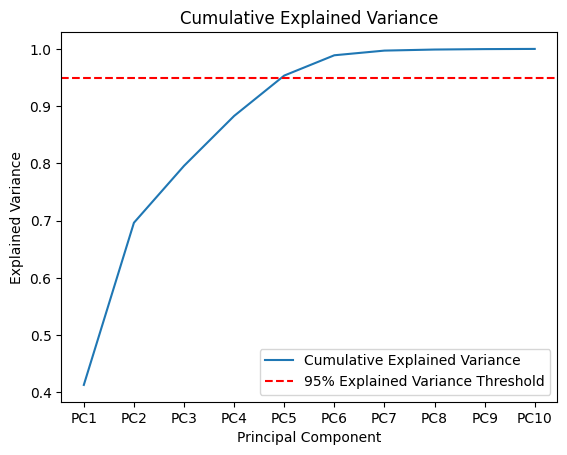

In [ ]:
plt.plot(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'], cumulative_variance, label='Cumulative Explained Variance')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Explained Variance Threshold')
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.legend();

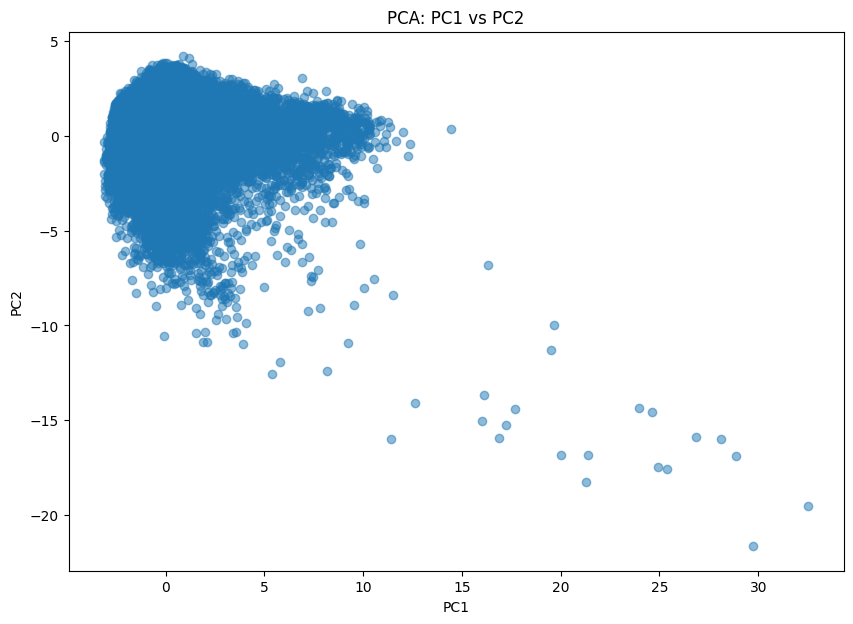

In [ ]:
# Scatter plot of the first two principal components
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2")
plt.show()


Loadings represent the correlation between the original features and the principal components. High absolute values of loadings indicate that the feature contributes significantly to the respective PC.

/tmp/ipykernel_4349/3696799131.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loading_df[labels_unique[i]], y=loading_df.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_4349/3696799131.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loading_df[labels_unique[i]], y=loading_df.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_4349/3696799131.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loading_df[labels_unique[i]], y=loading_df.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_4349/3696799131.py:15: FutureWa

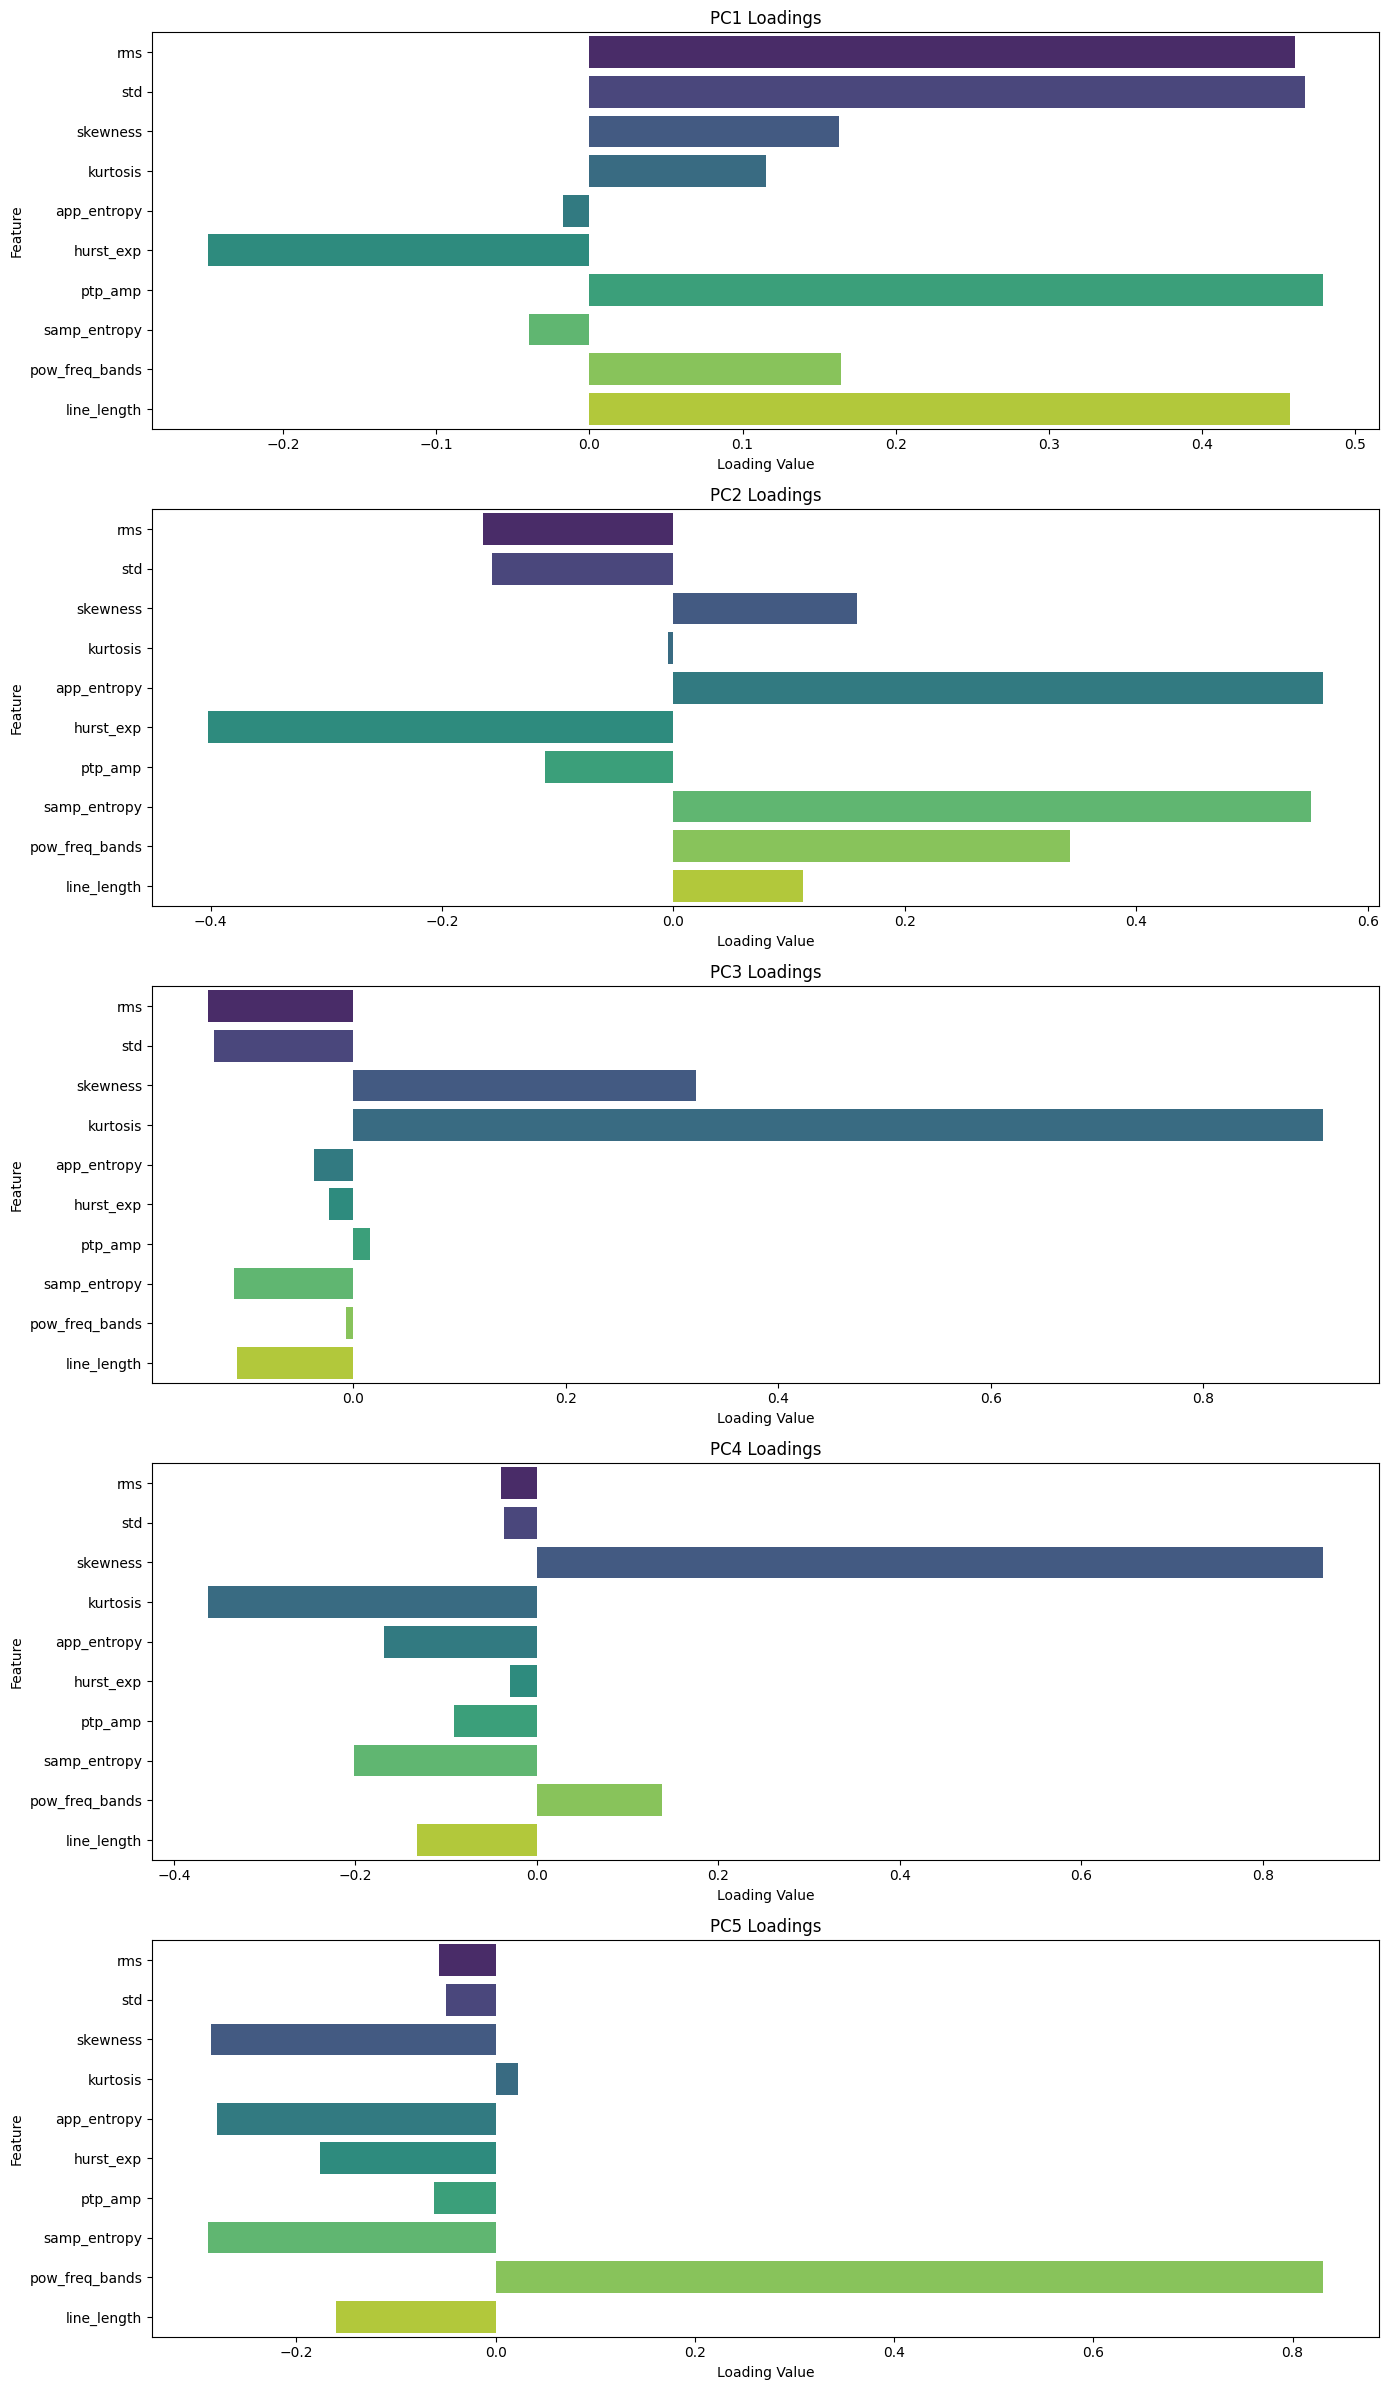

In [ ]:
# Get the loadings (components)
loadings = pca.components_
labels_unique = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']

# Create a DataFrame for loadings
loading_df = pd.DataFrame(loadings.T, columns=labels_unique, index=[
    "rms", "std", "skewness", "kurtosis", "app_entropy", "hurst_exp",
    "ptp_amp", "samp_entropy", "pow_freq_bands", "line_length"
])

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 24))
axes = axes.flatten()

for i in range(5):
    sns.barplot(x=loading_df[labels_unique[i]], y=loading_df.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{labels_unique[i]} Loadings')
    axes[i].set_xlabel('Loading Value')
    axes[i].set_ylabel('Feature')

plt.tight_layout()
plt.show()

rms, std, ptp_amp,line_length
hurst influence PC1 the msot

app_entropy, samp_entropy, pow_freq_bands 
hurst_exp influence PC2 the most

### transform the data 
using the first 5 PCs

In [ ]:
pca_data_5pcs = pca_data[:, :5]
pca_5 = PCA(n_components=5)
pca_5.fit(scaled_data)
pca_data_5pcs = pca_5.transform(scaled_data)

print(pca_data_5pcs.shape) #20 time windows * 2093 trials, 5pcs

(41860, 5)


save data to a file so i can use it for ml in a different script (same h5py format with labels for convenience)

In [35]:
print(labels)

[121 121 121 ... 124 124 124]


In [36]:
with h5py.File("MODE_PRINCIPAL_COMPS.h5", "w") as f:
    f.create_dataset('features', data=pca_data_5pcs)
    f.create_dataset('labels', data=labels)

In [37]:
with h5py.File("MODE_PRINCIPAL_COMPS.h5", "r") as f:
    features = f['features'][:]
    labels = f['labels'][:]
print(features.shape)
print(labels.shape)

(41860, 5)
(41860,)
